# Candidate selection and the next experiment

We combine prediction and reconstruction quality with representation diagnostics. The shortlist is a proposal to confirm on independent data, not a declaration of a winner based on test performance.

## Introduction

The analysis supports the selection of heads for subsequent experiments. We keep prediction quality, reconstruction and geometry separate. Definitions and limitations are described in [METHODOLOGY.md](METHODOLOGY.md), and execution instructions in [README.md](README.md).

### Assumptions

The evaluated pixels come from the saved partitions of one campaign; the result does not measure transfer to a new patient or acquisition. A positive annotation is an observed P; a missing annotation does not confirm the absence of a molecule. The unit of model comparison is the seed, not the pixel; duplicate tasks for the same condition and seed do not increase the number of repetitions. Candidate selection uses validation, while test provides subsequent confirmation.

### Notation

$X \in \mathbb{R}^{N\times M}$ denotes TIC-normalized spectra, $\hat X$ reconstructions, $Y \in \{0,1\}^{N\times C}$ annotations, and $A$ label availability. $Z=\mathrm{Enc}(X)$ is the latent representation used by the head and decoder; $U=(Z-\beta)/\gamma$ reverses the affine transformation of the final LayerNorm. Evidence states follow N=0, P=1, U=2; **state U and representation $U$ are different objects**. $s$ denotes the positive ranking score. $r$ is an independent training repetition.


In [1]:
import os
from pathlib import Path

import pandas as pd
from IPython.display import display

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.visualization import predictive as plots

current = Path.cwd().resolve()
repository_root = next(path for path in (current, *current.parents) if (path / "pyproject.toml").is_file())
notebook_directory = repository_root / "assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded"
settings_path = Path(os.environ.get("MSI_PREDICTIVE_SETTINGS", notebook_directory / "analysis_settings.yaml"))
settings = campaign.load_settings(settings_path)
RESULTS = notebook_directory / "part_7_head_selection_results"
RESULTS.mkdir(parents=True, exist_ok=True)


2026-09-08 10:28:55,492 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-08 10:28:55,495 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-08 10:28:55,833 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-08 10:28:55,835 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 23 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-08 10:28:55,837 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-08 10:28:55,838 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 30 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


## Validation ranking and the trade-off set

### Methodology

#### Theoretical

The ranking maximizes macro annotation_retrieval AP on validation. The Pareto front contains conditions that no other complete condition outperforms simultaneously in AP and mean Masserstein. Zeros/NaN are not replaced by favourable values.

#### Implementation

Each condition requires five independent seeds and shared contracts. Duplicates are averaged within a seed. Test AP and operational P/N are control columns; they do not affect the ranking or Pareto front. No arbitrary limit on reconstruction deterioration is imposed.

#### Figure descriptions

The table shows rank, seed counts, spread, validation/test AP in both populations, Masserstein and eligibility/Pareto flags. Plot: x=validation Masserstein, y=validation AP, point=condition; this plot summarizes the preceding seed distributions.


2026-09-08 10:29:00,839 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:250 | Audited 65 model manifests across 2 sources.


,source,condition,label,test_annotation_retrieval,test_operational_pn,train_annotation_retrieval,train_operational_pn,validation_annotation_retrieval,validation_operational_pn,test_annotation_retrieval_seeds,...,train_operational_pn_std,validation_annotation_retrieval_std,validation_operational_pn_std,validation_masserstein,complete_seeds,comparable_contracts,eligible,validation_rank,validation_pareto,next_step
6,predictive_initial,c37325811656,vpu (VariationalPULoss),0.682525,0.856821,0.672650,0.852727,0.686505,0.859713,5,...,0.003806,0.004703,0.004051,3.406413,True,True,True,1.0,True,Replicate on independent acquisition; test hea...
8,predictive_initial,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,0.680328,0.851859,0.672772,0.849087,0.686317,0.857774,5,...,0.007988,0.009074,0.007806,3.521350,True,True,True,2.0,False,Inspect paired effects and reconstruction tails
1,predictive_initial,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,0.677177,0.850677,0.666616,0.845123,0.683313,0.855153,5,...,0.006986,0.007354,0.006943,3.423377,True,True,True,3.0,False,Inspect paired effects and reconstruction tails
0,historical_bce,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),0.674615,0.849819,0.666368,0.847212,0.681748,0.855139,5,...,0.006751,0.006370,0.005275,3.392296,True,True,True,4.0,True,Replicate on independent acquisition; test hea...
2,predictive_initial,20c052d026cd,pnu_ce (ThreeStateCrossEntropyLoss),0.675515,0.831680,0.664540,0.822689,0.677200,0.834162,5,...,0.005276,0.003305,0.003147,3.377373,True,True,True,5.0,True,Replicate on independent acquisition; test hea...
7,predictive_initial,d1f9a150e163,pn_bce_per_class_positive_penalty (SignalMaske...,0.612543,0.864454,0.601531,0.864032,0.615271,0.873450,5,...,0.003484,0.004954,0.005523,3.397877,True,True,True,6.0,False,Inspect paired effects and reconstruction tails
4,predictive_initial,40ee4c7e8820,pn_bce_global_positive_penalty (SignalMaskedBC...,0.611467,0.863804,0.601301,0.864197,0.614366,0.872480,5,...,0.003284,0.004928,0.003619,3.363765,True,True,True,7.0,True,Replicate on independent acquisition; test hea...
5,predictive_initial,a4c7ac80c5c1,pn_bce_unweighted (SignalMaskedBCELoss),0.607922,0.863015,0.597078,0.862726,0.608850,0.870103,5,...,0.002357,0.005939,0.003720,3.459743,True,True,True,8.0,False,Inspect paired effects and reconstruction tails
3,predictive_initial,32e2c5ffe6e2,pu_ranking (SymmetricPURankingLoss),0.479651,0.658370,0.473830,0.656607,0.486163,0.666225,5,...,0.015756,0.023509,0.016187,3.401861,True,True,True,9.0,False,Inspect paired effects and reconstruction tails


2026-09-08 10:29:02,511 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_7_head_selection_results.


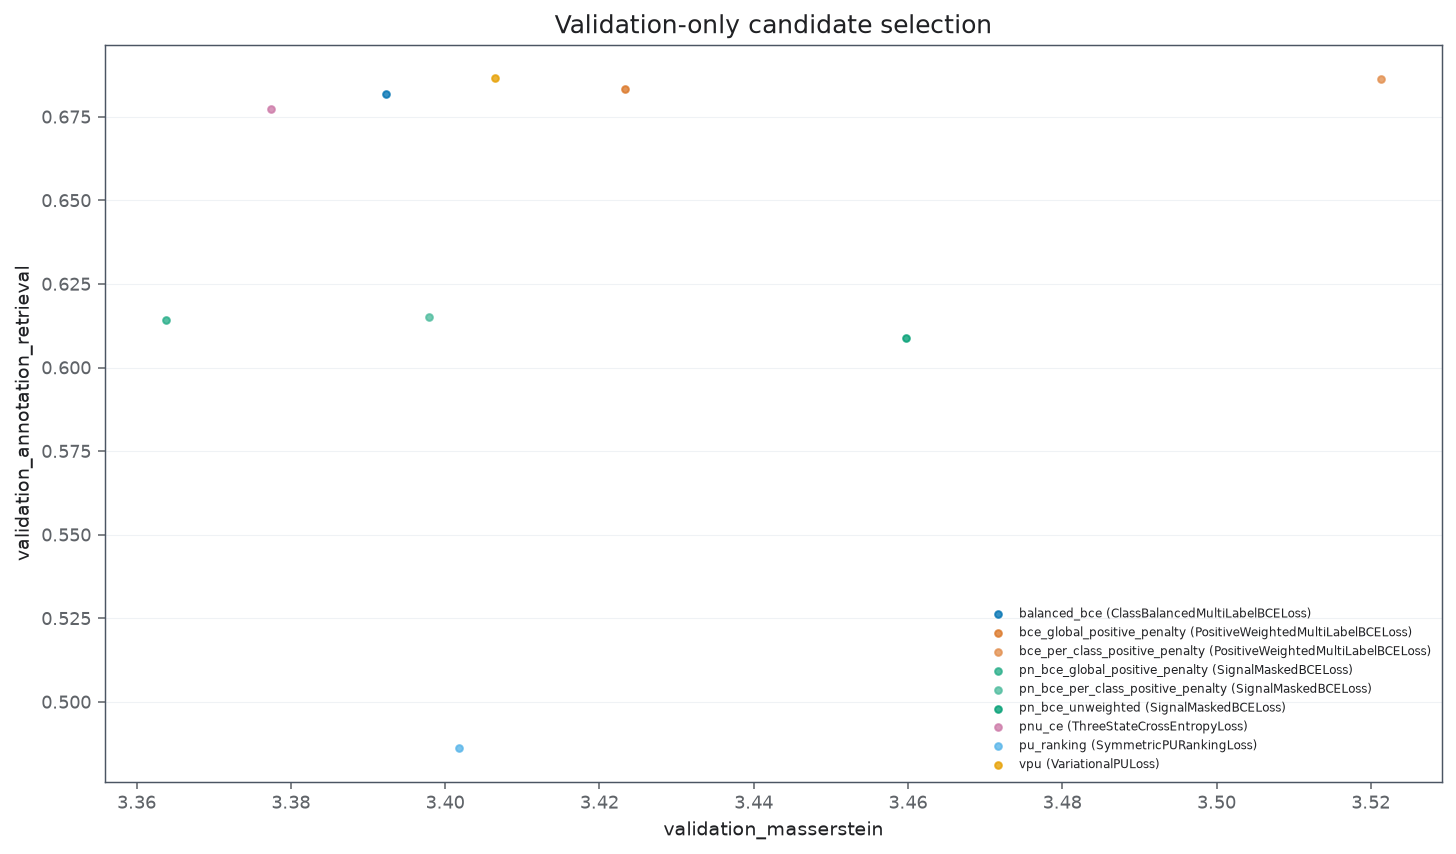

In [2]:
models, _ = campaign.inventory(settings)
prediction = cache.load_table(settings, "prediction")
reconstruction = cache.load_table(settings, "reconstruction")
decision = reports.decision_table(prediction, reconstruction, models, expected_seeds=settings["expected_seeds"])
display(decision)
plots.scatter(decision, x="validation_masserstein", y="validation_annotation_retrieval", title="Validation-only candidate selection").savefig(RESULTS / "validation_selection.png")
reports.save_tables(RESULTS, decision_table=decision)

### Remarks

Results have not yet been computed for the target campaign.

### Notes


## Relationships between geometry, prediction and reconstruction

### Methodology

#### Theoretical

We compare observations at the level of the same model and seed. The association of rank with AP describes covariation; it does not identify a cause or a preferred geometry for future regularization.

#### Implementation

Join only validation, Z, effective_rank and train_supported annotation AP. Each point retains model_id; several metrics from the same model are not treated as independent replicates.

#### Figure descriptions

x-axis=effective_rank(Z), y=macro AP; point=run, colour=head. Inspect together with seed variability, the ridge probe and reconstruction tails.


2026-09-08 10:29:03,803 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:198 | Saved 1 analytical tables in /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/07_09_26_predictive_expanded/part_7_head_selection_results.


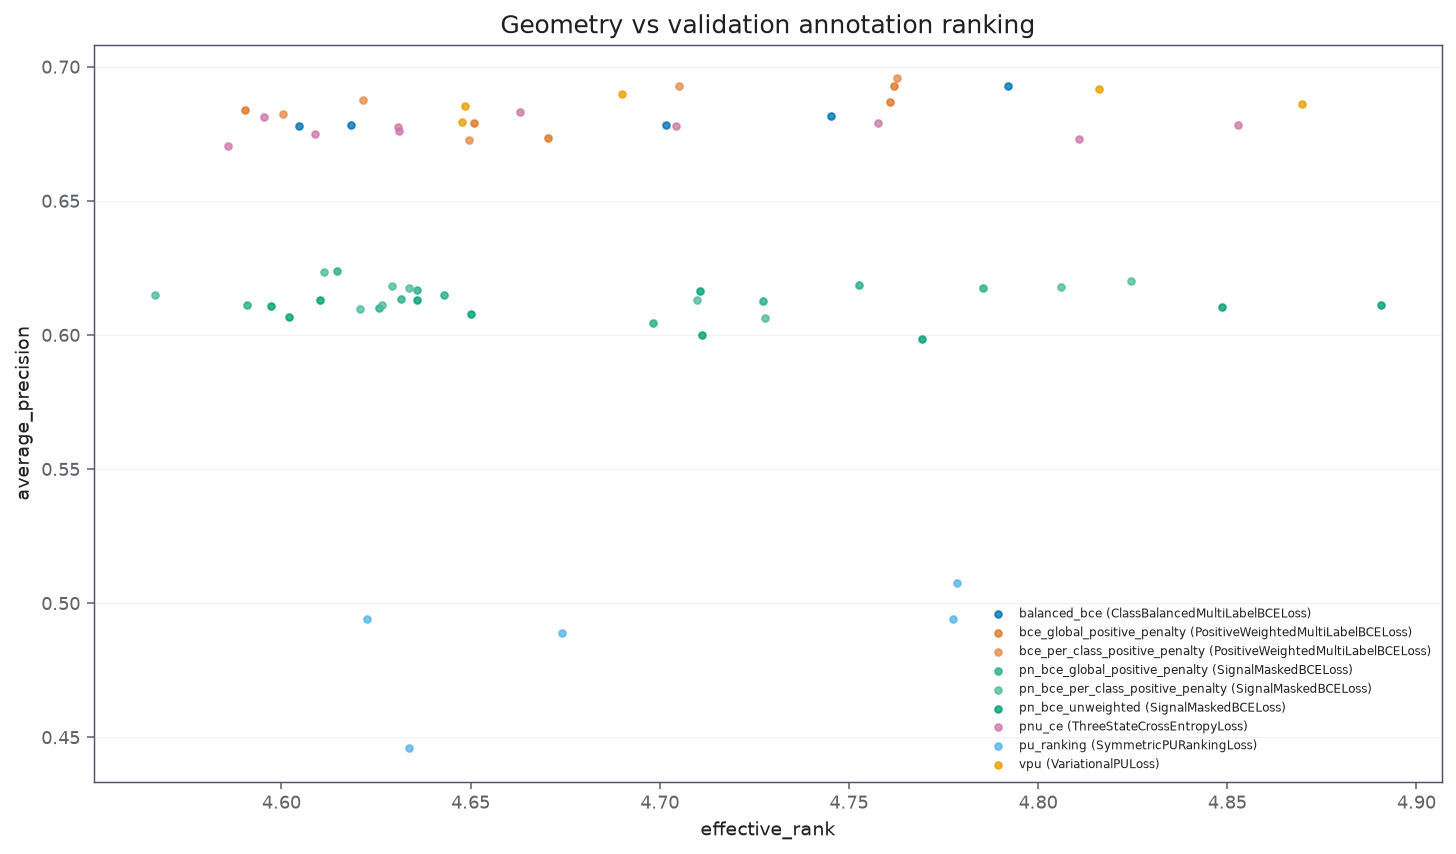

In [3]:
geometry = cache.load_table(settings, "geometry")
rank = geometry.query("split == 'validation' and space == 'z' and metric == 'effective_rank'")[["model_id", "value"]].rename(columns={"value": "effective_rank"})
quality = prediction.query("split == 'validation' and scope == 'train_supported' and population == 'annotation_retrieval' and metric == 'average_precision'")[["model_id", "label", "value"]].rename(columns={"value": "average_precision"})
relations = rank.merge(quality, on="model_id", validate="one_to_one")
plots.scatter(relations, x="effective_rank", y="average_precision", title="Geometry vs validation annotation ranking").savefig(RESULTS / "geometry_prediction.png")
reports.save_tables(RESULTS, geometry_prediction=relations)

### Remarks

Further experiments: VPU ± N penalty with identical remaining parameters; PU-ranking with a counterpart using N; selected heads × fixed contractivity; only then separate contrastivity and pretraining factors. Control head weight/gradient scale, training duration and checkpoint selection. Confirm transfer to a new acquisition; the current pixel split is insufficient.

### Notes


## Results / Summary

### LLM

An executable protocol and table exports have been prepared. Results from the target campaign are not yet available; this file does not contain an empirical conclusion that any head is superior. After execution, assess effect direction and magnitude, variation across seeds, completeness of pairs and limitations of the label definitions.

### Person
